What happens if I model QQQ daily returns as iid (independent and identically distributed) Gaussian with constant mean
and constant velocity?

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

print("Working environment ready.")

Working environment ready.


In [2]:
ticker = "QQQ"

qqq = yf.download(
    ticker,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

prices = qqq[["Close"]].copy()
prices = prices.rename(columns={"Close": "QQQ_close"})

prices["QQQ_log_return"] = np.log(
    prices["QQQ_close"] / prices["QQQ_close"].shift(1)
)

returns = prices["QQQ_log_return"].dropna()

returns.head()

Date
2015-01-05   -0.014778
2015-01-06   -0.013499
2015-01-07    0.012809
2015-01-08    0.018959
2015-01-09   -0.006605
Name: QQQ_log_return, dtype: float64

Assume a simple model of a constant mean on daily returns with random Gaussian noise. Fit a constant-mean,
constant-volatilty model with values from the returns data.

In [3]:
mu_hat = returns.mean()
sigma_hat = returns.std()

print(f"Estimated mean (mu): {mu_hat:.6f}")
print(f"Estimated std (sigma): {sigma_hat:.6f}")
print(f"Annualised volatility: {sigma_hat * np.sqrt(252):.2%}")

Estimated mean (mu): 0.000700
Estimated std (sigma): 0.013813
Annualised volatility: 21.93%


This basic model assumes that QQQ daily log returns are independently drawn from a Gaussian distribution with constant
mean and constant volatility. The estimated mean is the sample average return, and the esimated volaility is the sample
standard deviation of daily returns.

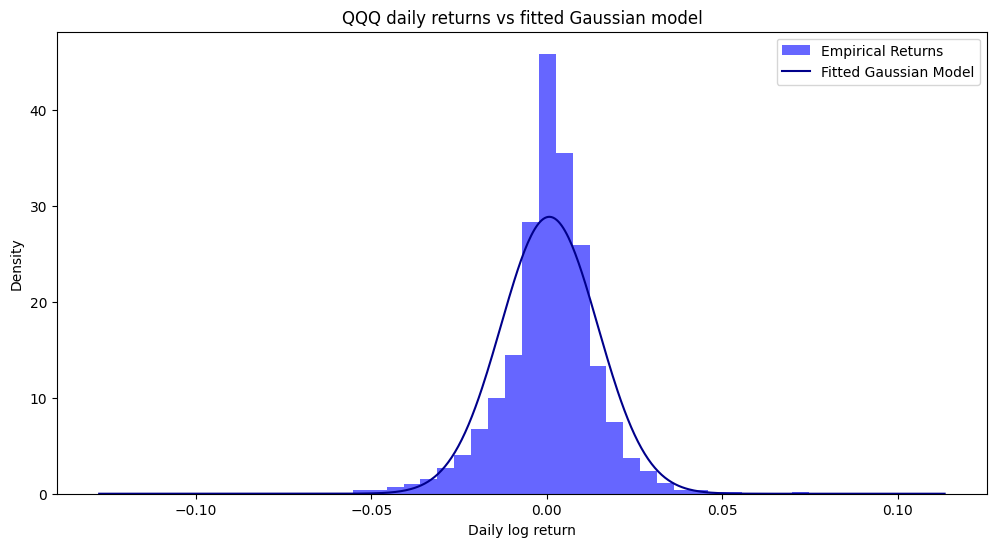

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(returns.min(), returns.max(), 500)
pdf = norm.pdf(x, loc=mu_hat, scale=sigma_hat)

ax.hist(returns, bins=50, density=True, alpha=0.6, color="b", label="Empirical Returns")
ax.plot(x, pdf, label="Fitted Gaussian Model", color='darkblue')

ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.set_title("QQQ daily returns vs fitted Gaussian model")
ax.legend()
plt.show()

Compute kurtosis and analyse 'extreme moves'.

In [7]:
from scipy.stats import skew, kurtosis

print(f"Mean: {returns.mean():.6f}")
print(f"Volatilty: {returns.std():.6f}")
print(f"Skewness: {skew(returns):.6f}")
print(f"\nKurtosis: {kurtosis(returns):.6f}")

mu_hat = returns.mean()
sigma_hat = returns.std()

z_scores = (returns - mu_hat) / sigma_hat

empirical_2sigma = (np.abs(z_scores) > 2).mean()
empirical_3sigma = (np.abs(z_scores) > 3).mean()

gaussian_2sigma = 2 * (1 - norm.cdf(2))
gaussian_3sigma = 2 * (1 - norm.cdf(3))

print(f"\nEmpirical |z| > 2: {empirical_2sigma:.2%}")
print(f"Gaussian  |z| > 2: {gaussian_2sigma:.2%}")

print(f"\nEmpirical |z| > 3: {empirical_3sigma:.2%}")
print(f"Gaussian  |z| > 3: {gaussian_3sigma:.2%}")

Mean: 0.000700
Volatilty: 0.013813
Skewness: -0.397611

Kurtosis: 7.641888

Empirical |z| > 2: 5.15%
Gaussian  |z| > 2: 4.55%

Empirical |z| > 3: 1.39%
Gaussian  |z| > 3: 0.27%


The fitted Gaussian model gives a reasonable first approximation to the centre of the return distribution, but the histogram alone is not sufficient to judge the tails. Since the central peak is large, tail differences are hard to see visually. To assess this more carefully, I use excess kurtosis and the percentage of returns lying beyond 2 and 3 standard deviations. Positive excess kurtosis, together with more extreme observations than predicted by the Gaussian model, would suggest that QQQ returns are more sharply peaked and heavy-tailed than the iid Gaussian baseline.

Compare empirical volatilty.

In [8]:
empirical_volatilty = returns.std()
empirical_annualised_volatility = empirical_volatilty * np.sqrt(252)

print(f"\nEmpirical daily volatility: {empirical_volatilty:.6f}")
print(f"Empirical annualised volatility: {empirical_annualised_volatility:.2%}")


Empirical daily volatility: 0.013813
Empirical annualised volatility: 21.93%


Compute rolling volatility over a 60-day window.

In [10]:
rolling_volatility = returns.rolling(window=60).std()
rolling_annualised_volatility = rolling_volatility * np.sqrt(252)

print(f"\nAverage rolling daily volatility over 60-day period: {rolling_volatility.mean():.6f}")
print(f"Average rolling annualised volatility over 60-day period: {rolling_annualised_volatility.mean():.2%}")


Average rolling daily volatility over 60-day period: 0.012616
Average rolling annualised volatility over 60-day period: 20.03%


Compare on plot.

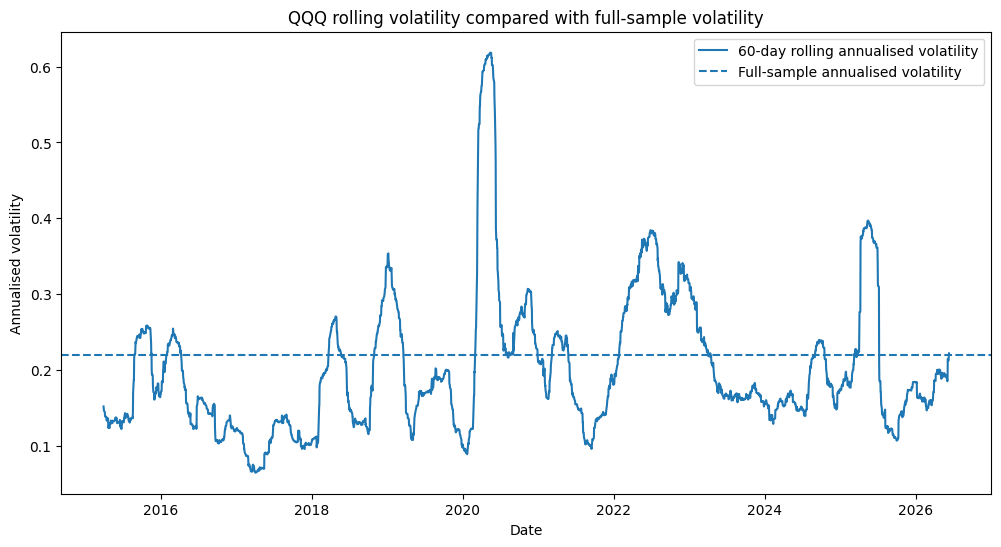

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rolling_annualised_volatility.index,
    rolling_annualised_volatility,
    label="60-day rolling annualised volatility"
)

ax.axhline(
    empirical_annualised_volatility,
    linestyle="--",
    label="Full-sample annualised volatility"
)

ax.set_title("QQQ rolling volatility compared with full-sample volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised volatility")
ax.legend()

plt.show()

The full-sample volatility gives a single estimate of average risk over the entire period. However, as shown on the
plot, the rolling volatility shows that QQQ's volatility changes drastically over time. This is clear evidence over the
constant volatility model.

Add daily log returns for QQQ above.

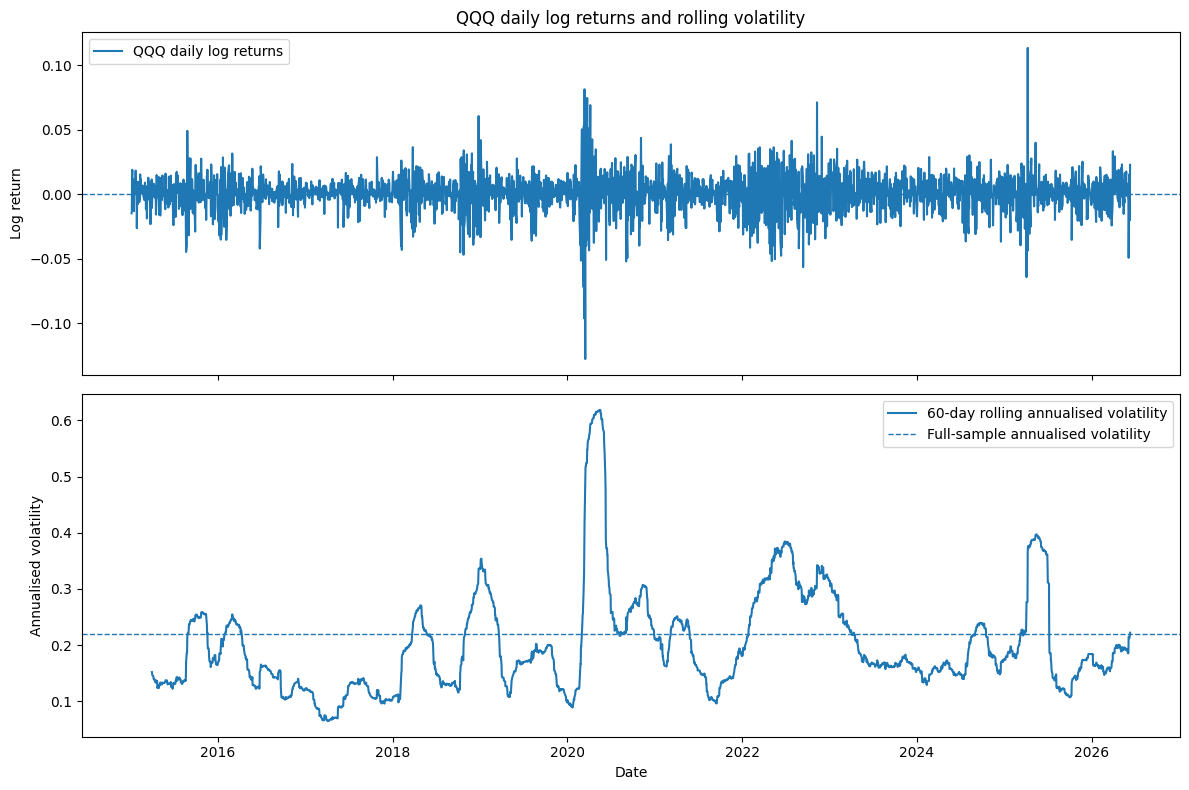

In [12]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)

# Top plot: daily log returns
ax1.plot(returns.index, returns, label="QQQ daily log returns")
ax1.axhline(0, linestyle="--", linewidth=1)
ax1.set_title("QQQ daily log returns and rolling volatility")
ax1.set_ylabel("Log return")
ax1.legend()

# Bottom plot: rolling annualised volatility
ax2.plot(
    rolling_annualised_volatility.index,
    rolling_annualised_volatility,
    label="60-day rolling annualised volatility"
)

ax2.axhline(
    empirical_annualised_volatility,
    linestyle="--",
    linewidth=1,
    label="Full-sample annualised volatility"
)

ax2.set_xlabel("Date")
ax2.set_ylabel("Annualised volatility")
ax2.legend()

plt.tight_layout()
plt.show()

The upper plot shows daily log returns and the lower plot shows the previous rolling voltailty compared to the full-sample
volatility. Periods with large positive or negative log returns tend to cluster together and correspond to increases in
rolling volatility. This suggests volatility is time-varying rather than constant, violating the constant-volatility
assumption in the iid Gaussian baseline model.

This section is about why iid Gaussian returns are a poor model for financial data.

The iid Gaussian model assumes daily returns are independent and identically distributed with constant mean and constant
volatility. Whilst this is a useful, simple baseline model, because it is easy to estimate and interpretable, it is
unrealistic for financial return data.

First, returns show volatility clustering. Periods of large market movements tend to be followed by further large movements,
whilst calm periods tend to persist. This means volatility is time-varying rather than constant.

Second, financial returns often have heavier tails than a Gaussian distribution. Extreme returns occur more frequently than
a normal model would predict, making the Gaussian assumption dangerous for risk modelling.

Third, the independence assumption is too strong. Even if raw returns have weak autocorrelation, squared returns or absolute
returns often show dependence over time, indicating predictable structure in volatility.

Therefore, the iid Gaussian model is useful as a baseline but not as a realistic model of financial returns. More appropriate
models may include GARCH models, stochastic volatility models, or Bayesian time-series models with time-varying parameters.

In [13]:
returns_autocorr = returns.autocorr(lag=1)
squared_returns_autocorr = (returns ** 2).autocorr(lag=1)

print(f"Autocorrelation of returns (lag 1): {returns_autocorr:.4f}")
print(f"Autocorrelation of squared returns (lag 1): {squared_returns_autocorr:.4f}")

Autocorrelation of returns (lag 1): -0.1046
Autocorrelation of squared returns (lag 1): 0.3636


The autocorrelation of raw returns is usually small, suggesting limited simple linear predictability in daily returns. However,
the autocorrelation of squared returns is often larger, indicating persistence in volatility. This supports the idea that
volatility is more predictable than returns themselves.